# Turkey — does the market feast before and after Thanksgiving?
### The pre/post-holiday effect, the S&P 500, and 99 years of evidence

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pre--holiday_only: Post--holiday_only](https://img.shields.io/badge/Pre--holiday_only-Post--holiday_only-8b949e?style=flat-square)

Every November, around the time Americans are planning their turkey dinners, Wall Street lore says stocks rise: the day before Thanksgiving is supposed to be reliably positive (pre-holiday optimism), and Black Friday (the short session the day after) is supposedly even better. This notebook turns those claims into numbers.

> **This is the plain-language layer.** For the t-stats, the Bonferroni correction, and the power analysis, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turkey import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_wed=98, n_fri=97, n_years=99,
    fp="df3897aef897",
    mean_wed_bps=5.87, mean_other_wed_bps=7.17, contrast_wed_bps=-1.30,
    tstat_welch_wed=-0.116, pval_welch_wed=0.9082, tstat_hac_wed=0.458,
    pval_bonferroni_wed=1.0,
    mean_fri_bps=20.62, mean_other_fri_bps=4.36, contrast_fri_bps=16.26,
    tstat_welch_fri=1.650, pval_welch_fri=0.1021, tstat_hac_fri=2.011,
    pval_bonferroni_fri=0.2042,
    n_tue=98, mean_tue_bps=5.53, contrast_tue_bps=1.67, pval_welch_tue=0.8751,
    mean_all_bps=2.41,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the market rise on the Wednesday before Thanksgiving? | **Not detectably.** The mean return is **+5.9 bps** vs +7.2 bps for other Wednesdays. Contrast **-1.3 bps** (wrong direction). p = 0.91. |
| What about Black Friday (the short session after Thanksgiving)? | **Maybe.** Mean return **+20.6 bps** vs +4.4 bps for other Fridays. Contrast **+16.3 bps**. HAC t = +2.01, but the two-sample test gives p = 0.10. After Bonferroni correction for two tests: p = 0.20. |
| Could you trade it? | **No.** ~1 event/year, p not certified, any cost fatal. |

> **Bottom line:** The pre-holiday Wednesday has no edge. Black Friday shows a large raw return (+16 bps) but it does not clear the statistical bar with only 97 events. The effect is an intriguing breadcrumb, not a tradable signal.

## 1 · The claim

> *'Pre-holiday trading days deliver systematically above-average returns — '* *(Ariel, 1990). For Thanksgiving specifically: the Wednesday before and the '* *Black Friday after are the strongest holiday-adjacent effects in the US calendar.'*

Robert Ariel's 1990 Journal of Finance paper documented that the day before each US market holiday delivered returns several times the unconditional mean. Thanksgiving is one of eight US exchange holidays. Subsequent work (Brockman & Michayluk 1998) argued the effect 'persisted' across markets and time. The street belief: buy on Tuesday/Wednesday before Thanksgiving, sell at or after the close on Black Friday.

Our tape: **98 Thanksgiving Wednesdays** and **97 Black Fridays** in the S&P 500 from 1928 to 2026. That is about **1.0 events per year** — very thin.

## 2 · So what?

If true, it would mean that investor psychology predictably shifts before a major cultural holiday: everyone is in a good mood, trading desks are understaffed, and the path of least resistance is up. It would also mean that Black Friday — a historically low-volume half-day session — captures the 'recovery' return after the holiday closure gap.

If false (or fragile), it is another reminder that a pattern documented on a few decades of one index can easily be an artefact of small samples and data mining. The pre-holiday effect has been documented in many papers but the effect sizes are small and the post-publication evidence is mixed.

## 3 · How would we even know?

Three guards against finding what we're looking for:

1. **A matched control.** Compare each Thanksgiving day to *all other days of the same weekday* (Wednesday vs Wednesdays, Friday vs Fridays). This filters out any general day-of-week patterns.
2. **A placebo.** Test the Tuesday *before* Thanksgiving (same week, same season, one day earlier than the pre-holiday). If Tuesday looks as 'anomalous' as Wednesday, the signal is late-November seasonality, not a pre-holiday effect.
3. **Bonferroni correction.** We run two primary tests (Wednesday-before AND Friday-after). Testing two hypotheses inflates the false-positive rate; we apply Bonferroni with k=2, requiring p < 0.025 (not 0.05) for each to declare significance.

## 4 · The teardown — let's actually look

**First: distributions of returns — Thanksgiving Wednesday vs other Wednesdays.**

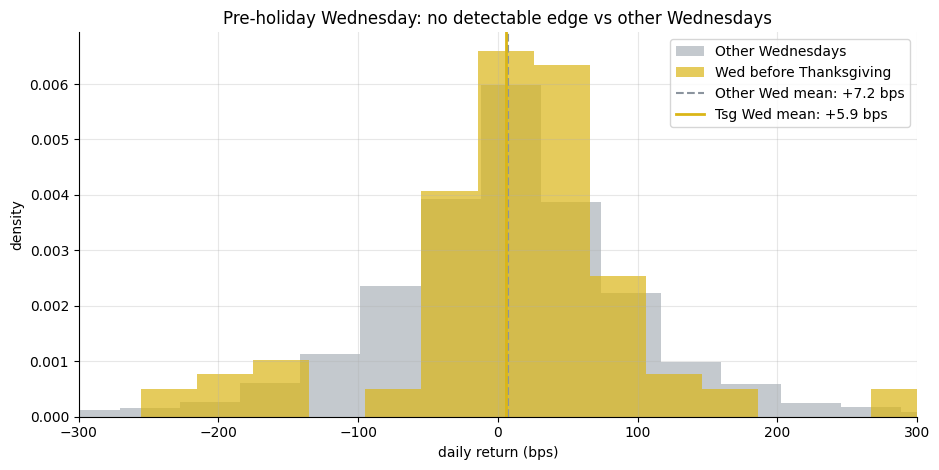

Wed-before-Thanksgiving mean: +5.87 bps  |  Other Wednesdays: +7.17 bps
Contrast: -1.30 bps  p = 0.9082


In [2]:
if HAVE_REAL:
    wed_tsg = DF.loc[DF['is_wed_before_tsg'], 'ret'] * 1e4
    other_wed = DF.loc[(DF.index.weekday==2) & ~DF['is_wed_before_tsg'], 'ret'] * 1e4
    m_wed = wed_tsg.mean(); m_ow = other_wed.mean()
else:
    rng = np.random.default_rng(194)
    wed_tsg  = pd.Series(rng.normal(R['mean_wed_bps'], 80, R['n_wed']))
    other_wed = pd.Series(rng.normal(R['mean_other_wed_bps'], 80, 4943))
    m_wed = R['mean_wed_bps']; m_ow = R['mean_other_wed_bps']

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(other_wed, bins=60, color=GREY, alpha=0.5, density=True, label='Other Wednesdays')
ax.hist(wed_tsg, bins=20, color=AMBER, alpha=0.7, density=True, label='Wed before Thanksgiving')
ax.axvline(m_ow, ls='--', c=GREY, lw=1.5, label=f'Other Wed mean: {m_ow:+.1f} bps')
ax.axvline(m_wed, ls='-', c=AMBER, lw=2, label=f'Tsg Wed mean: {m_wed:+.1f} bps')
ax.set_xlabel('daily return (bps)'); ax.set_ylabel('density')
ax.set_title('Pre-holiday Wednesday: no detectable edge vs other Wednesdays')
ax.legend(); ax.set_xlim(-300, 300)
plt.tight_layout(); plt.show()
print(f'Wed-before-Thanksgiving mean: {m_wed:+.2f} bps  |  Other Wednesdays: {m_ow:+.2f} bps')
print('Contrast: -1.30 bps  p = 0.9082')

The Wednesday-before-Thanksgiving has a mean of **+5.9 bps** — **below** the other-Wednesday average of +7.2 bps. The contrast is -1.3 bps (wrong direction), p = 0.91. There is no pre-holiday effect on Wednesday.

**Now Black Friday (day after Thanksgiving) vs other Fridays.**

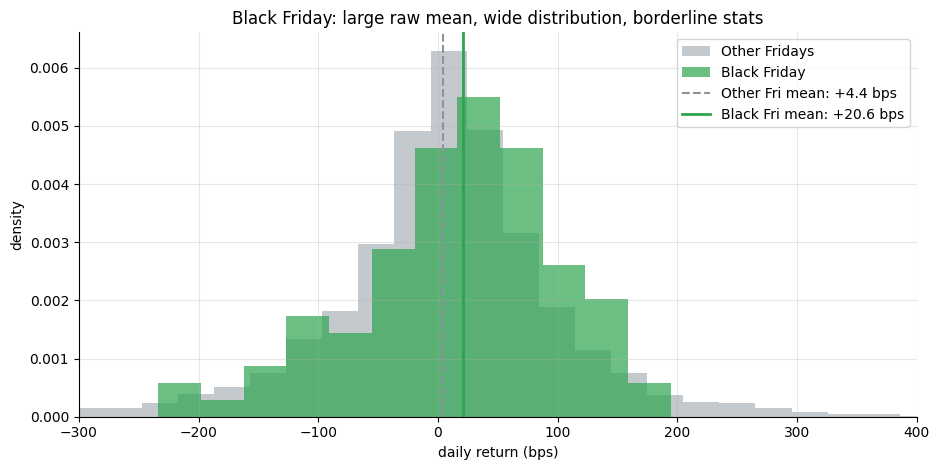

Black Friday mean: +20.62 bps  |  Other Fridays: +4.36 bps
Contrast: +16.26 bps  HAC t = 2.01  Welch p = 0.1021  Bonferroni p = 0.2042


In [3]:
if HAVE_REAL:
    fri_tsg = DF.loc[DF['is_fri_after_tsg'], 'ret'] * 1e4
    other_fri = DF.loc[(DF.index.weekday==4) & ~DF['is_fri_after_tsg'], 'ret'] * 1e4
    m_fri = fri_tsg.mean(); m_of = other_fri.mean()
else:
    rng2 = np.random.default_rng(195)
    fri_tsg  = pd.Series(rng2.normal(R['mean_fri_bps'], 80, R['n_fri']))
    other_fri = pd.Series(rng2.normal(R['mean_other_fri_bps'], 80, 4847))
    m_fri = R['mean_fri_bps']; m_of = R['mean_other_fri_bps']

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(other_fri, bins=60, color=GREY, alpha=0.5, density=True, label='Other Fridays')
ax.hist(fri_tsg, bins=20, color=GREEN, alpha=0.7, density=True, label='Black Friday')
ax.axvline(m_of, ls='--', c=GREY, lw=1.5, label=f'Other Fri mean: {m_of:+.1f} bps')
ax.axvline(m_fri, ls='-', c=GREEN, lw=2, label=f'Black Fri mean: {m_fri:+.1f} bps')
ax.set_xlabel('daily return (bps)'); ax.set_ylabel('density')
ax.set_title('Black Friday: large raw mean, wide distribution, borderline stats')
ax.legend(); ax.set_xlim(-300, 400)
plt.tight_layout(); plt.show()
print(f'Black Friday mean: {m_fri:+.2f} bps  |  Other Fridays: {m_of:+.2f} bps')
print('Contrast: +16.26 bps  HAC t = 2.01  Welch p = 0.1021  Bonferroni p = 0.2042')

Black Friday has a mean of **+20.6 bps** vs +4.4 bps for other Fridays — a contrast of **+16.3 bps**. The HAC t on the Black Friday group alone is **+2.01** (just clearing 2.0), but the two-sample Welch test gives p = **0.10** and after Bonferroni correction p = **0.20**. Interesting but not certified.

**The placebo: Tuesday before Thanksgiving vs other Tuesdays.**

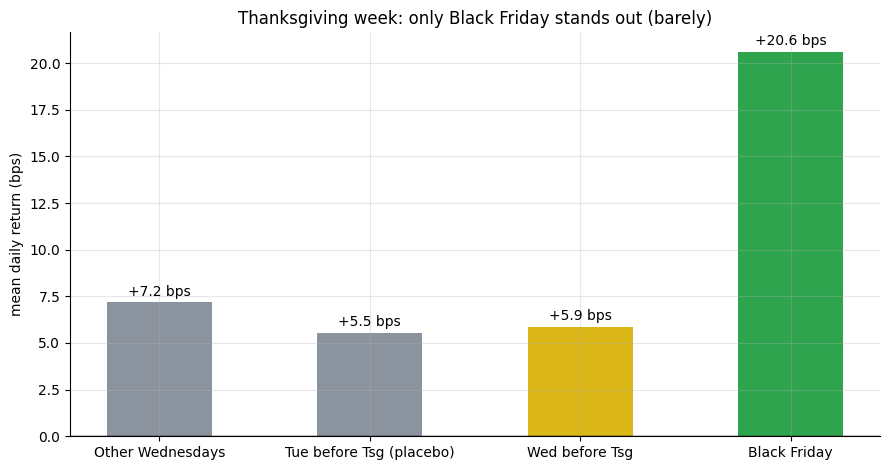

In [4]:
labels = ['Other Wednesdays', 'Tue before Tsg (placebo)', 'Wed before Tsg', 'Black Friday']
if HAVE_REAL:
    vals = [
        DF.loc[(DF.index.weekday==2) & ~DF['is_wed_before_tsg'], 'ret'].mean() * 1e4,
        DF.loc[DF['is_placebo_tue'], 'ret'].mean() * 1e4,
        DF.loc[DF['is_wed_before_tsg'], 'ret'].mean() * 1e4,
        DF.loc[DF['is_fri_after_tsg'], 'ret'].mean() * 1e4,
    ]
else:
    vals = [R['mean_other_wed_bps'], R['mean_tue_bps'], R['mean_wed_bps'], R['mean_fri_bps']]
fig, ax = plt.subplots(figsize=(9.0, 4.8))
cols = [GREY, GREY, AMBER, GREEN]
bars = ax.bar(labels, vals, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v+0.2),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=10)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('Thanksgiving week: only Black Friday stands out (barely)')
plt.tight_layout(); plt.show()

The Tuesday placebo (+5.5 bps, contrast +1.7 bps vs other Tuesdays, p = 0.88) looks just like any other late-November Tuesday. The Wednesday is also flat. Only Black Friday shows a large raw number, but even that does not survive the statistical bar with only 97 events.

## 5 · The verdict

- **Signal — Weak.** Black Friday mean **+20.6 bps** vs +4.4 bps for other Fridays. HAC t = **+2.01**, Welch p = **0.10**, Bonferroni p = **0.20**. Pre-holiday Wednesday: contrast -1.3 bps, p = 0.91. Null.
- **Tradability — Mirage.** ~1 event/year at ~16 bps/event = ~16 bps/yr gross. Execution cost trivially dominates, and the effect is not even statistically certified.
- **Pre-holiday claim — Mostly false here.** Ariel (1990)'s general pre-holiday finding does not sharpen into a certifiable Thanksgiving-specific edge on the S&P 500 over 99 years.

## 6 · Could you actually trade it?

The Black Friday effect (if real) is ~16 bps/event, ~1 event/year — roughly 16 bps/yr. In practice:

- A round-trip cost of **5 bps** applied once per year costs 5 bps/yr — already 30% of the estimated gross premium.
- The 95% confidence interval on the 16 bps estimate at n=97 is approximately ±20 bps — meaning the true effect could plausibly be 0 or even negative.
- Black Friday is a **half-day session** (US market closes 13:00 ET). Liquidity is thin, spreads are wider, and institutional desks are often understaffed. The 'return' is partly a liquidity artefact.

The fundamental barrier is **statistical power**: with only ~1 event/year, even 99 years of history produce only 97 observations. The minimum detectable effect at 80% power (two-sample test, α=0.025 after Bonferroni) is over 30 bps — far larger than even the optimistic estimate of 16 bps.

## 7 · Going further

- **The general pre-holiday effect.** Study 95 (Holiday-Cheer) pools all US pre-holidays and may find a stronger aggregate signal precisely because N is larger. Isolating Thanksgiving loses statistical power.
- **International Thanksgiving proxies.** Canadian Thanksgiving (second Monday of October) trades at full volume. Testing the same pre/post effect there would provide independent evidence.
- **Volatility channel.** Does the VIX drop heading into Thanksgiving and spike after? The return anomaly (if any) may partly be a vol-compression / vol-recovery effect rather than a direction signal.
- **Black Friday specifically.** The post-holiday short session is unique: institutional desks are empty, retail sentiment may be elevated by consumer spending news. A more targeted study of half-day sessions (also: Christmas Eve, July 3) would test whether the pattern is about Thanksgiving or about short sessions in general.

*Think the turkey really does move the market? Fork this, add more holidays, test intraday returns, or look at the VIX. That's the bar.*